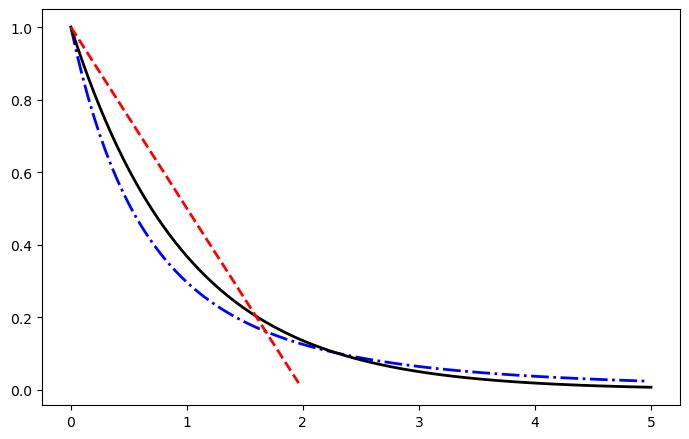

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ── GPD density (replicates R QRM::dGPD) ─────────────────────────────────────
# xi > 0: Pareto tail,  support x >= 0
# xi = 0: Exponential,  support x >= 0
# xi < 0: Beta (bounded), support 0 <= x <= -beta/xi
def dGPD(x, xi, beta=1.0):
    x   = np.asarray(x, dtype=float)
    out = np.zeros_like(x)
    if abs(xi) < 1e-10:                          # Exponential
        mask = x >= 0
        out[mask] = (1/beta) * np.exp(-x[mask] / beta)
    else:
        inner = 1 + xi * x / beta
        mask  = inner > 0
        out[mask] = (1/beta) * inner[mask]**(-1/xi - 1)
    return out

n  = 100
sp = 5
r  = [0.5, 0, -0.5]

# dist1: Pareto, xi = 0.5
x1 = np.arange(0.001, 5.001, 0.05)
y1 = dGPD(x1, r[0], 1)

# dist2: Exponential, xi = 0
x2 = np.concatenate([[0], sp * np.arange(1, n + 1) / n])
y2 = dGPD(x2, r[1], 1)

# dist3: Beta, xi = -0.5, upper bound = -1/xi = 2
step = -1 / r[2] / n           # = 0.02
x3   = np.arange(0.001, 100 * step + 0.001, step)
y3   = dGPD(x3, r[2], 1)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(x1, y1, color='blue',  linewidth=2, linestyle='dashdot', label=r'$\xi = 0.5$  (Pareto)')
ax.plot(x2, y2, color='black', linewidth=2, linestyle='solid',   label=r'$\xi = 0$    (Exponential)')
ax.plot(x3, y3, color='red',   linewidth=2, linestyle='dashed',  label=r'$\xi = -0.5$ (Beta)')

# ax.set_title("Generalized Pareto Densities", fontsize=11)
# ax.legend(frameon=False, fontsize=9)
ax.grid(False)

plt.tight_layout()
plt.savefig("GPD_densities.png", dpi=200, transparent=True, bbox_inches='tight')
plt.show()

**Cell 1 — Imports and configuration**

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

OUTPUT_DIR = os.getcwd()

N = 100
SP = 5
XI_VALUES = [0.5, 0, -0.5]   # Pareto, Exponential, Beta
BETA = 1.0

**Cell 2 — GPD density function**

In [2]:
def dGPD(x, xi, beta=1.0):
    """Generalized Pareto density (replicates R QRM::dGPD).
    xi > 0: Pareto tail, support x >= 0
    xi = 0: Exponential, support x >= 0
    xi < 0: Beta (bounded), support 0 <= x <= -beta/xi
    """
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x)
    if abs(xi) < 1e-10:
        mask = x >= 0
        out[mask] = (1 / beta) * np.exp(-x[mask] / beta)
    else:
        inner = 1 + xi * x / beta
        mask = inner > 0
        out[mask] = (1 / beta) * inner[mask] ** (-1 / xi - 1)
    return out

**Cell 3 — Compute densities for the three GPD shapes**

In [6]:
xi_pareto, xi_exp, xi_beta = XI_VALUES

X_MAX = 5.0
N_POINTS = 200
x_grid = np.linspace(0, X_MAX, N_POINTS)

y1 = dGPD(x_grid, xi_pareto, BETA)
y2 = dGPD(x_grid, xi_exp, BETA)

# Beta has bounded support: 0 <= x <= -beta/xi
beta_upper_bound = -BETA / xi_beta
mask_beta = x_grid <= beta_upper_bound
x3 = x_grid[mask_beta]
y3 = dGPD(x3, xi_beta, BETA)

**Cell 4 — Plot, display and save**

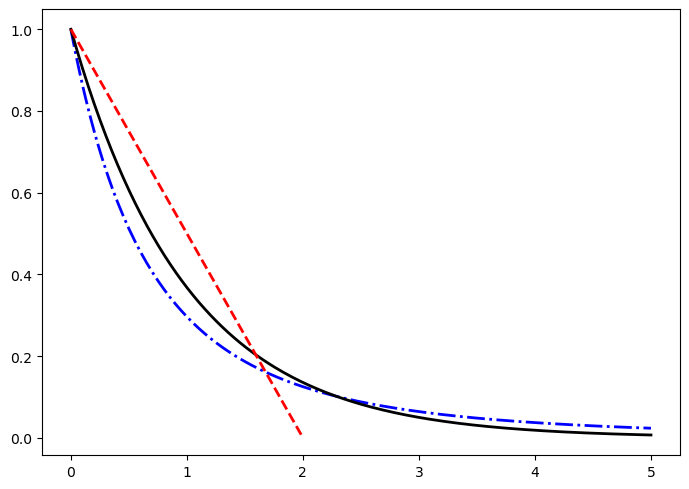

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(x_grid, y1, color='blue',  linewidth=2, linestyle='dashdot', label=r'$\xi = 0.5$  (Pareto)')
ax.plot(x_grid, y2, color='black', linewidth=2, linestyle='solid',   label=r'$\xi = 0$    (Exponential)')
ax.plot(x3,     y3, color='red',   linewidth=2, linestyle='dashed',  label=r'$\xi = -0.5$ (Beta)')

ax.grid(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "GPD_densities.png"),
            dpi=200, transparent=True, bbox_inches='tight')
plt.show()